# One pixel through the whole pipeline — Villaviciosa

Every stage of the README pipeline, run with the pipeline's own functions
on the full Villaviciosa cube, and after each stage **one pixel pulled out
and looked at**: what it received, what was decided about it, and why.
Then inside MAREA: its NDWI curves under every candidate clock, the
parameters those clocks buy, the likelihood arithmetic written out term by
term, the optimum — and what all of that does to its elevation.

The pixel is the *upstream witness* of `marea_one_pixel.ipynb` (row 624,
column 295 of the 915×915 grid; 8 km along the water from the open sea),
chosen there by an explicit rule. Nothing below is tuned to it.

## 0 · Setup and the pixel

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import ndtr

import pyintertidal as pit
from pyintertidal import SentinelCube, TideService, viz, water as W
from pyintertidal import geometry, marea, overpass
from pyintertidal import tide_estimators as te
from pyintertidal.cube import open_cube
pit.net.use_system_certificates()     # corporate TLS (overpass lookup)

SITE        = "villaviciosa"
TIME_EXTENT = ("2016-01-01", "2025-12-31")
CACHE       = "ndwi_cube_villaviciosa_grande_10y.nc"
PIXEL       = (624, 295)             # (row, col): the upstream witness

aoi = pit.sites.get(SITE)
R, Cc = PIXEL
TIDE = "#2a6f97"; MUD = "#b08968"; RED = "#c1121f"; INK = "#14313c"
print(aoi)

AOI('Villaviciosa', 44.4 km², [-5.455, 43.470, -5.375, 43.548])


## 1 · Stage: the datacube (download once, stream forever)

`SentinelCube` fetches the archive ONCE — one openEO job, all scenes,
the bands the detector needs (green B03, near-infrared B08) plus the scene
classification SCL — into one netCDF that every later stage streams. For
our pixel, "downloading" means: three numbers per visit.

In [2]:
cube = SentinelCube(aoi, TIME_EXTENT, water="ndwi", cache_path=CACHE,
                    resolution=10)
cube.ensure()                       # cached: no network touched
transform, crs = cube.grid
print(f"{len(cube.dates)} scenes · grid {cube.shape[0]}x{cube.shape[1]} "
      f"@ {abs(transform.a):g} m · bands {cube.bands}")

# the pixel's raw record, straight from the cube
ds, arrays, t_dim = open_cube(cube.cache_path, cube.bands)
try:
    b03 = np.asarray(arrays["B03"][:, R, Cc].values, float)
    b08 = np.asarray(arrays["B08"][:, R, Cc].values, float)
    scl = np.nan_to_num(np.asarray(arrays["SCL"][:, R, Cc].values, float),
                        nan=0).astype(int)
finally:
    ds.close()
dates = np.array(cube.dates)
t_idx = pd.to_datetime(dates)

# the detector's index, computed exactly as the pipeline does it
ndwi = (b03 - b08) / np.where(b03 + b08 != 0, b03 + b08, np.nan)

raw = pd.DataFrame({"date": dates, "B03 (green)": b03, "B08 (NIR)": b08,
                    "SCL": scl, "NDWI": np.round(ndwi, 3)})
print("\nfirst visits of the pixel (reflectance x 10 000):")
print(raw.head(8).to_string(index=False))

[cube] using cache ndwi_cube_villaviciosa_grande_10y.nc


1379 scenes · grid 915x915 @ 10 m · bands ('B03', 'B08', 'SCL')



first visits of the pixel (reflectance x 10 000):
      date  B03 (green)  B08 (NIR)  SCL   NDWI
2016-01-01        328.0       40.0    6  0.783
2016-01-11        487.0      546.0    5 -0.057
2016-01-18       5356.0     6120.0    9 -0.067
2016-01-21       6168.0     6468.0    9 -0.024
2016-02-10       6896.0     6944.0    8 -0.003
2016-02-17       1122.0     1782.0    8 -0.227
2016-03-11       4548.0     6192.0    9 -0.153
2016-03-18        683.0      239.0    6  0.482


In [3]:
SCL_NAME = {0: "no data", 1: "saturated", 2: "dark area", 3: "cloud shadow",
            4: "vegetation", 5: "bare ground", 6: "water", 7: "unclassified",
            8: "cloud (medium)", 9: "cloud (high)", 10: "thin cirrus", 11: "snow"}
bad_px = np.isin(scl, list(W.BAD_CLASSES))      # 3, 8, 9, 10
clr_px = np.isin(scl, list(W.CLEAR_CLASSES))    # 4, 5, 6
print("visits by SCL class:")
for k in range(12):
    if (scl == k).sum():
        tag = ("cloud/shadow" if k in W.BAD_CLASSES else
               "clear" if k in W.CLEAR_CLASSES else "neither")
        print(f"  {k:2d} {SCL_NAME[k]:15s} {int((scl == k).sum()):5d}   {tag}")
print(f"clear-class visits: {int(clr_px.sum())} of {len(dates)}; the rest carry "
      "no usable look at this pixel")

visits by SCL class:
   3 cloud shadow       92   cloud/shadow
   4 vegetation          1   clear
   5 bare ground       190   clear
   6 water              97   clear
   7 unclassified      156   neither
   8 cloud (medium)    243   cloud/shadow
   9 cloud (high)      488   cloud/shadow
  10 thin cirrus       112   cloud/shadow
clear-class visits: 288 of 1379; the rest carry no usable look at this pixel


## 2 · Stage: the water threshold (Otsu on the site's own clearest scenes)

NDWI separates water from land, but the right cut is site-dependent —
turbid estuarine water sits low. The pipeline lets the archive decide:
pool the clear-sky NDWI of the 12 clearest scenes and take Otsu's split.
The study adopts 0.0 explicitly, informed by that number.

[water] Otsu on 409,121 clear pixels from 12 scenes → +0.250  (clipped — the sample was not clearly bimodal; set the threshold manually)
pixel: 288 clear visits -> 167 above the cut (WET), 121 below (DRY)


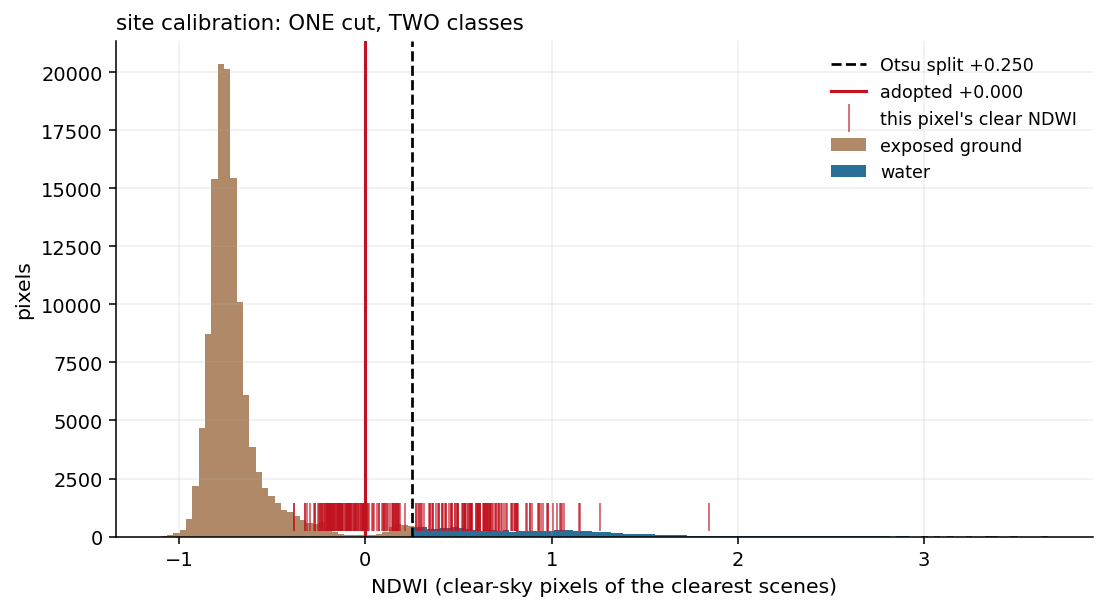

In [4]:
otsu, info = W.calibrate_threshold(cube, n_scenes=12)
NDWI_THRESHOLD = 0.0
fig, ax = viz.plot_otsu_ndwi(info["sample"], otsu, adopted=NDWI_THRESHOLD,
                             title="site calibration: ONE cut, TWO classes")
# where does OUR pixel's record sit against that cut?
clear_px = np.isin(scl, list(W.CLEAR_CLASSES)) & np.isfinite(ndwi)
ax.plot(ndwi[clear_px], np.full(clear_px.sum(), ax.get_ylim()[1] * 0.04),
        "|", color=RED, ms=14, alpha=0.6, label="this pixel's clear NDWI")
ax.legend(fontsize=9, frameon=False)
n_wet = int((ndwi[clear_px] > NDWI_THRESHOLD).sum())
print(f"pixel: {clear_px.sum()} clear visits -> {n_wet} above the cut "
      f"(WET), {clear_px.sum() - n_wet} below (DRY)")

## 3 · Stage: the reference map and the cloud screen

Two decisions live here. **Scene level**: the clean scenes (<5 % cloud)
vote a *reference map* — stable water / stable land / transition — and
every scene is then scored by its cloudiness *over the transition zone
only*, where it matters; scenes above 10 % are dropped (`filter_dates`).
**Pixel level**: within a kept scene, the pixel's own SCL class still
decides whether that observation counts. Our pixel keeps what survives
both.

In [5]:
CLEAN_SCENE_MAX_BAD, STABLE_THRESHOLD, TRANSITION_BUFFER_PX = 0.05, 0.95, 10
reference_map, cloud_pct = pit.reference_and_clouds(
    cube, threshold=NDWI_THRESHOLD, bad_classes=W.BAD_CLASSES,
    clean_scene_max_bad=CLEAN_SCENE_MAX_BAD,
    stable_threshold=STABLE_THRESHOLD,
    transition_buffer_px=TRANSITION_BUFFER_PX)
CLOUD_THRESHOLD = 0.10
usable_dates = pit.filter_dates(cloud_pct, cloud_threshold=CLOUD_THRESHOLD)

cls = {0: "transition", 1: "stable water", 2: "stable land"}
print(f"reference map: " + ", ".join(
    f"{cls[k]} {int((reference_map == k).sum()):,} px" for k in cls))
print(f"the pixel is class {reference_map[R, Cc]} = "
      f"{cls[int(reference_map[R, Cc])]}")

in_usable = np.isin(dates, usable_dates)
kept = in_usable & clear_px
print(f"scene screen: {len(usable_dates)} of {len(dates)} scenes usable "
      f"(<= {CLOUD_THRESHOLD:.0%} cloud over the transition zone)")
print(f"pixel screen: of those, {int(in_usable.sum() - kept.sum())} visits "
      f"have a cloudy SCL at THIS pixel -> {int(kept.sum())} observations "
      f"survive for it")

reference map: transition 116,011 px, stable water 24,924 px, stable land 696,290 px
the pixel is class 0 = transition
scene screen: 305 of 1379 scenes usable (<= 10% cloud over the transition zone)
pixel screen: of those, 106 visits have a cloudy SCL at THIS pixel -> 199 observations survive for it


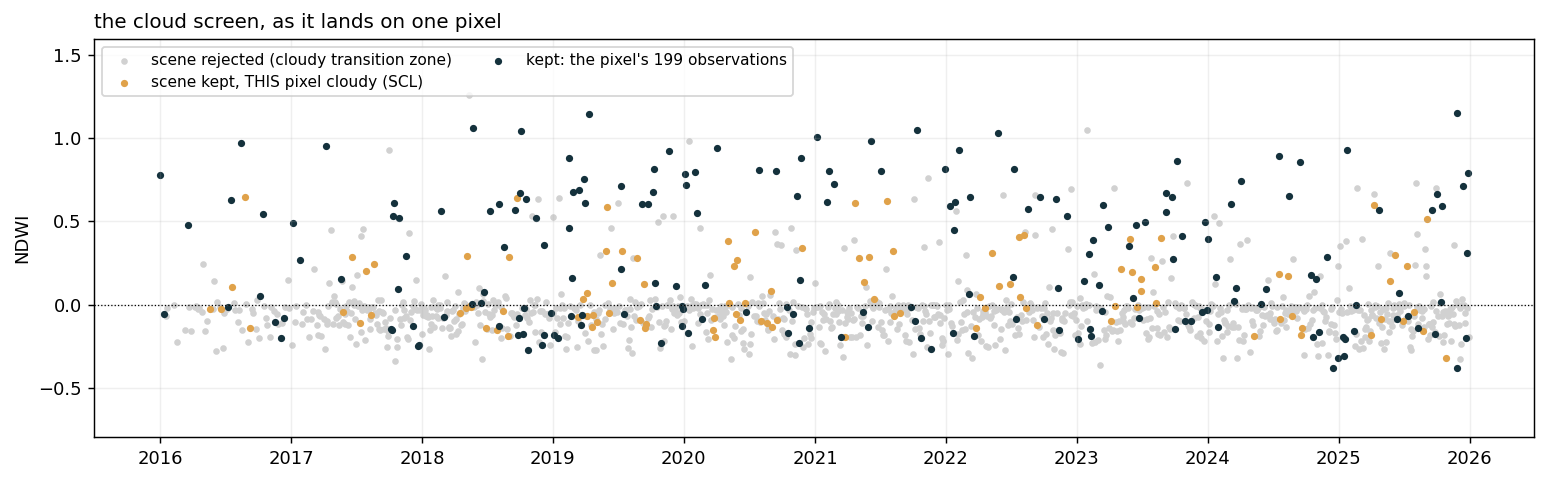

In [6]:
fig, ax = plt.subplots(figsize=(12, 3.8), dpi=130)
ax.scatter(t_idx[~in_usable], ndwi[~in_usable], s=7, c="0.82",
           label="scene rejected (cloudy transition zone)")
ax.scatter(t_idx[in_usable & ~clear_px], ndwi[in_usable & ~clear_px], s=9,
           c="#e0a24a", label="scene kept, THIS pixel cloudy (SCL)")
ax.scatter(t_idx[kept], ndwi[kept], s=9, c=INK,
           label=f"kept: the pixel's {int(kept.sum())} observations")
ax.axhline(NDWI_THRESHOLD, color="k", lw=0.7, ls=":")
ax.set_ylim(-0.8, 1.6); ax.set_ylabel("NDWI"); ax.grid(alpha=0.2)
ax.legend(fontsize=8.5, ncol=2, loc="upper left")
ax.set_title("the cloud screen, as it lands on one pixel", loc="left",
             fontsize=11)
fig.tight_layout();

## 4 · Stage: water frequency and the intertidal decision (multi-Otsu)

Over the usable dates, each pixel's *water frequency* is the fraction of
its clear observations called wet. Inside the transition class that
histogram mixes three populations — almost never wet, truly intertidal,
almost always wet — and a 3-class Otsu finds the two valleys. The study
adopts a wider window on purpose (0.05–0.95) and lets per-pixel quality
control trim the ends.

multi-Otsu valleys [0.21, 0.66] · adopted [0.05, 0.95] · intertidal pixels 30,806
the pixel: water frequency 0.613 (needs >= 15 obs) -> INTERTIDAL


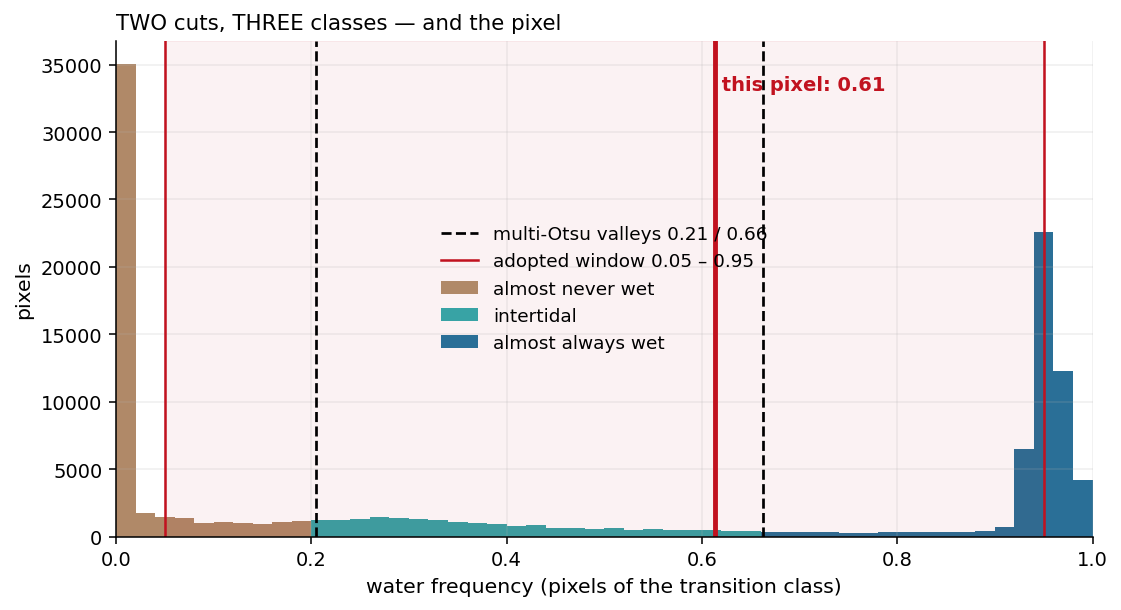

In [7]:
MIN_OBS = max(8, round(0.05 * len(usable_dates)))
water_freq = pit.water_frequency(cube, dates=usable_dates,
                                 threshold=NDWI_THRESHOLD, min_obs=MIN_OBS)
transition = reference_map == 0
otsu_low, otsu_high = pit.multiotsu_window(water_freq, transition)
WF_LOW, WF_HIGH = 0.05, 0.95
polygon_mask = aoi.raster_mask(transform, crs, reference_map.shape)
intertidal = pit.intertidal_mask(water_freq, reference_map, WF_LOW, WF_HIGH,
                                 aoi_mask=polygon_mask)
wf_px = float(water_freq[R, Cc])
print(f"multi-Otsu valleys [{otsu_low:.2f}, {otsu_high:.2f}] · adopted "
      f"[{WF_LOW}, {WF_HIGH}] · intertidal pixels {int(intertidal.sum()):,}")
print(f"the pixel: water frequency {wf_px:.3f} (needs >= {MIN_OBS} obs) -> "
      f"{'INTERTIDAL' if intertidal[R, Cc] else 'NOT intertidal'}")

fig, ax = viz.plot_otsu_wf(water_freq, transition, (otsu_low, otsu_high),
                           adopted=(WF_LOW, WF_HIGH),
                           title="TWO cuts, THREE classes — and the pixel")
ax.axvline(wf_px, color=RED, lw=2.5)
ax.text(wf_px, ax.get_ylim()[1] * 0.9, f" this pixel: {wf_px:.2f}",
        color=RED, fontsize=10, fontweight="bold");

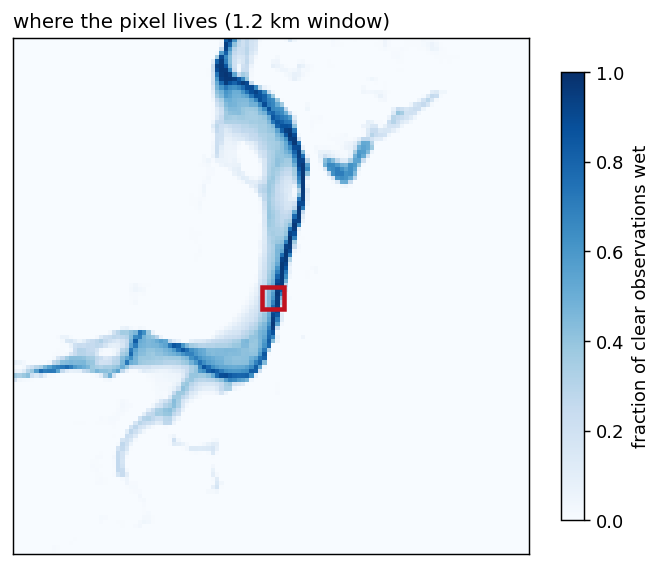

In [8]:
# the neighbourhood: 1.2 km around the pixel in the water-frequency map
h_ = 60
sl = (slice(max(R - h_, 0), R + h_), slice(max(Cc - h_, 0), Cc + h_))
fig, ax = plt.subplots(figsize=(6.4, 5.6), dpi=130)
im = ax.imshow(water_freq[sl], cmap="Blues", vmin=0, vmax=1)   # viz.plot_water_frequency's scale
ax.plot(Cc - sl[1].start, R - sl[0].start, "s", ms=12, mfc="none",
        mec=RED, mew=2.5)
plt.colorbar(im, ax=ax, shrink=0.8, label="fraction of clear observations wet")
ax.set_xticks([]); ax.set_yticks([])
ax.set_title("where the pixel lives (1.2 km window)", loc="left",
             fontsize=11);

## 5 · Stage: the tide at every visit

EOT20, evaluated at the mid-channel point at the exact overpass instant of
each usable scene. From here on each of the pixel's observations carries a
water level; the next section puts that level on the x-axis, where the
wet/dry record turns from noise into a step.

[tides] model EOT20 already cached


[tides] EOT20 @ (43.540, -5.381) → 305 dates, range [-2.27, 1.22] m
199 observations of the pixel carry a tide level (range -2.27 to +1.22 m)


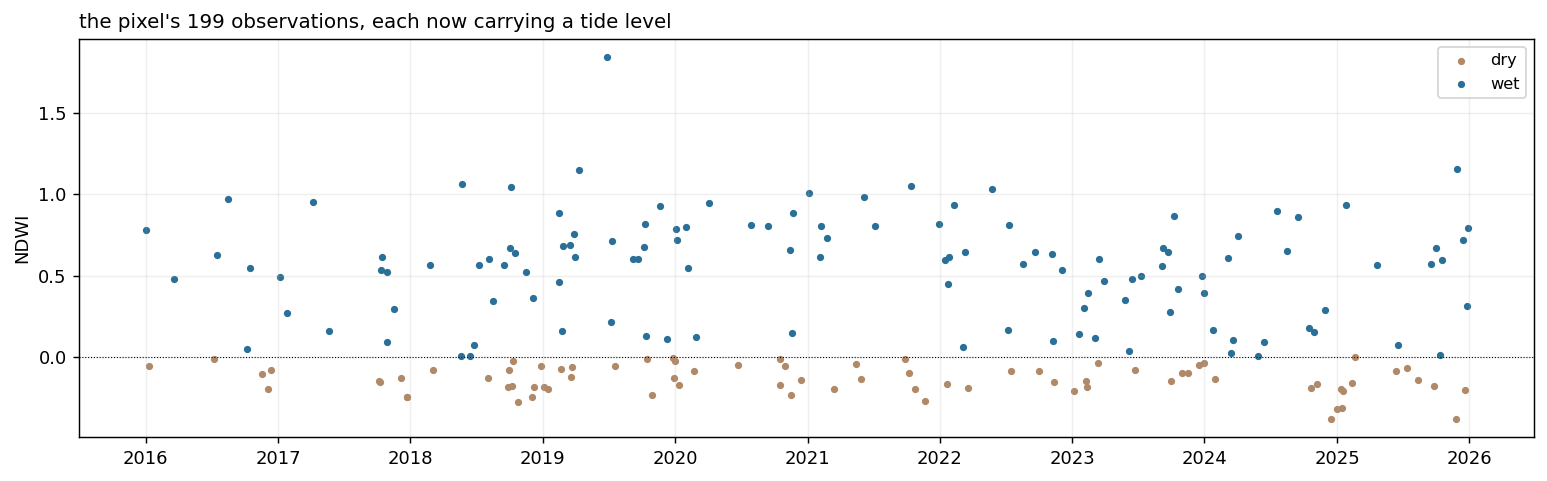

In [9]:
try:
    tide_point = pit.water_centroid(reference_map, transform, crs)
except ValueError:                 # no stable-water class in this map
    lon_c, lat_c = aoi.centroid
    tide_point = (lat_c, lon_c)
tides = TideService(model="EOT20", directory="./tide_models",
                    location=tide_point)
tide_heights = tides.heights_for(aoi, usable_dates)

h_all = np.array([tide_heights.get(d, np.nan) for d in dates])
obs = kept & np.isfinite(h_all)
h_o, y_o, w_o, d_o = h_all[obs], ndwi[obs], ndwi[obs] > NDWI_THRESHOLD, dates[obs]
print(f"{int(obs.sum())} observations of the pixel carry a tide level "
      f"(range {h_o.min():+.2f} to {h_o.max():+.2f} m)")

fig, ax = plt.subplots(figsize=(12, 3.8), dpi=130)
ax.scatter(t_idx[obs][~w_o], y_o[~w_o], s=9, c=MUD, label="dry")
ax.scatter(t_idx[obs][w_o], y_o[w_o], s=9, c=TIDE, label="wet")
ax.set_title(f"the pixel's {int(obs.sum())} observations, each now carrying "
             "a tide level", loc="left", fontsize=11)
ax.axhline(0, color="k", lw=0.6, ls=":"); ax.grid(alpha=0.2)
ax.set_ylabel("NDWI"); ax.legend(fontsize=9)
fig.tight_layout();

## 6 · Inside MAREA — geometry, band, and the clock bank

MAREA's own recipe (`marea.reconstruct`), step by step on the same
products: the **mouth** is the permanent sea touching the image border;
**s** is the geodesic distance from it through water-occupiable ground;
the flat is cut into **6 quantile bands of s**; each band gets one clock
$\tau$. The **bank** holds the mouth tide shifted by every candidate
$\tau$, from one tide-model call.

In [10]:
sea   = np.isfinite(water_freq) & (water_freq >= 0.90)
inter = intertidal
seeds = geometry.mouth_seeds(sea)
s_m   = geometry.along_distance(sea | inter, seeds, 10.0)
s_px  = float(s_m[R, Cc]) / 1000.0

keep_idx = np.flatnonzero(inter.ravel())
s_all = s_m.ravel()[keep_idx] / 1000.0
edges, centers, band_of = te.make_bands(s_all, 6)
my_pos = np.flatnonzero(keep_idx == R * reference_map.shape[1] + Cc)[0]
k_px = int(band_of[my_pos])
print(f"pixel: s = {s_px:.2f} km along the water -> band {k_px} "
      f"(centre {centers[k_px]:.2f} km, {int((band_of == k_px).sum()):,} px)")
print("band centres (km):", np.round(centers, 2))

bb = dict(aoi.bbox); bb.setdefault("crs", "EPSG:4326")
times = overpass.get_overpass_times(bb, TIME_EXTENT, verbose=False)
t_real = pd.DatetimeIndex(pd.to_datetime(
    [times[d] for d in d_o])).tz_localize(None)
TAUS = np.arange(-60.0, 121.0, 6.0)
lat_c = 0.5 * (bb["south"] + bb["north"]); lon_c = 0.5 * (bb["west"] + bb["east"])
bank, rising = marea.build_bank(lat_c, lon_c, t_real, bank_taus=list(TAUS))
h_tau = {float(t): bank.at(float(t)) for t in TAUS}
print(f"bank ready: the pixel's {len(t_real)} observations x "
      f"{len(TAUS)} candidate clocks")

pixel: s = 7.95 km along the water -> band 5 (centre 7.84 km, 5,004 px)
band centres (km): [1.92 3.47 4.12 4.53 5.41 7.84]


Modelling tides with EOT20

bank ready: the pixel's 199 observations x 31 candidate clocks

### 6a · The pixel's NDWI curves under the candidate clocks

The pixel model is $\mathrm{NDWI}(h)=a+b\,\Phi\!\big(\tfrac{h-z}{\sigma}\big)$.
For each clock $\tau$ the observations keep their NDWI and only move
along $h$; the curve is refitted from scratch — $(z,\sigma)$ on a grid,
$(a,b)$ in closed form, exactly the sweep `marea.invert_series` uses.
Watch the parameters move with the clock.

 tau (min)  z (m)  sigma (m)      a     b    rms
     -30.0 -0.305       0.45 -0.106 0.745 0.2744
       0.0 -0.217       0.32 -0.103 0.771 0.2338
      24.0 -0.246       0.45 -0.135 0.835 0.2228
      60.0 -0.217       0.45 -0.118 0.810 0.2508
      90.0 -0.334       0.85 -0.173 0.887 0.3000

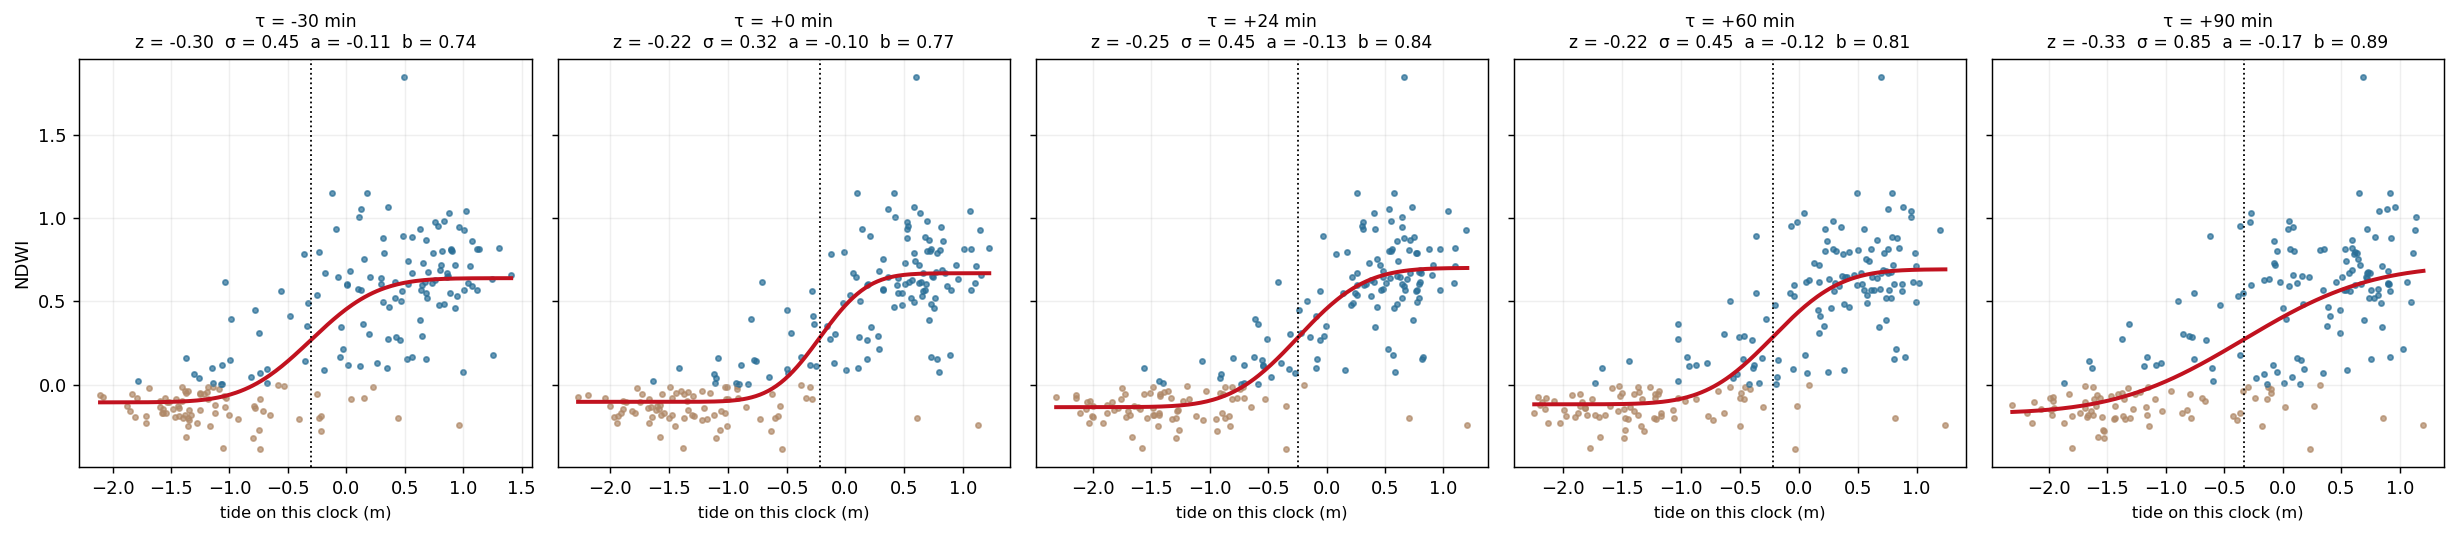

In [11]:
# the product's own sigma grid ends at 0.65 m; on a pixel this
# blurred it saturates and the profile goes flat, so the WALK
# extends it (to 1.10 m) purely to see the surface — the shipped
# product keeps marea.SG_GRID and simply clips sigma there
SG_GRID = np.array(list(marea.SG_GRID) + [0.85, 1.10])
Z_GRID = np.linspace(h_o.min(), h_o.max(), 120)

def fit_curve(h, y):
    """(z, sigma, a, b, rms): grid over (z, sigma), closed-form (a, b)."""
    best = None
    for zc in Z_GRID:
        for sg in SG_GRID:
            phi = ndtr((h - zc) / sg)
            A = np.column_stack([np.ones_like(phi), phi])
            coef, res, *_ = np.linalg.lstsq(A, y, rcond=None)
            sse = float(res[0]) if res.size else float(
                np.sum((y - A @ coef) ** 2))
            if best is None or sse < best[0]:
                best = (sse, zc, sg, coef)
    sse, zc, sg, (a, b) = best
    return float(zc), float(sg), float(a), float(b), float(np.sqrt(sse / len(y)))

SHOW = [-30.0, 0.0, 24.0, 60.0, 90.0]
rows = []
fig, axs = plt.subplots(1, len(SHOW), figsize=(19, 4.2), dpi=130,
                        sharey=True)
for ax, tau in zip(axs, SHOW):
    h = h_tau[tau]
    zc, sg, a, b, rms = fit_curve(h, y_o)
    rows.append({"tau (min)": tau, "z (m)": round(zc, 3),
                 "sigma (m)": round(sg, 3), "a": round(a, 3),
                 "b": round(b, 3), "rms": round(rms, 4)})
    ax.scatter(h[~w_o], y_o[~w_o], s=8, c=MUD, alpha=0.7)
    ax.scatter(h[w_o], y_o[w_o], s=8, c=TIDE, alpha=0.7)
    hg = np.linspace(h.min(), h.max(), 200)
    ax.plot(hg, a + b * ndtr((hg - zc) / sg), color=RED, lw=2.2)
    ax.axvline(zc, ls=":", color="k", lw=1)
    ax.set_title(f"τ = {tau:+.0f} min\nz = {zc:+.2f}  σ = {sg:.2f}  "
                 f"a = {a:+.2f}  b = {b:.2f}", fontsize=9.5)
    ax.set_xlabel("tide on this clock (m)", fontsize=9); ax.grid(alpha=0.2)
axs[0].set_ylabel("NDWI")
fig.tight_layout()
params = pd.DataFrame(rows)
print(params.to_string(index=False))

### 6b · The likelihood, operation by operation

MAREA does not score the NDWI curve: it scores the **binary** record. The
model becomes $P_t=\Phi\!\big(\tfrac{h_t-z}{\sigma}\big)$ — the
probability of a wet call at visit $t$ — and the Bernoulli log-likelihood
adds one term per visit:

$$\ell(\tau;z,\sigma)=\sum_t\Big[\,y_t\log P_t+(1-y_t)\log(1-P_t)\Big],
\qquad y_t\in\{0,1\}.$$

Below, the arithmetic for the first visits under the ocean clock with that
clock's best $(z,\sigma)$ — then the same sum for every clock.

In [12]:
P_CLIP = 1e-6

def loglik_terms(h, y_bin, zc, sg):
    P = np.clip(ndtr((h - zc) / sg), P_CLIP, 1 - P_CLIP)
    return np.where(y_bin, np.log(P), np.log1p(-P)), P

def profile(h, y_bin):
    """max over the (z, sigma) grid of the summed terms: profiling."""
    best = (-np.inf, np.nan, np.nan)
    for zc in Z_GRID:
        for sg in SG_GRID:
            ll = float(loglik_terms(h, y_bin, zc, sg)[0].sum())
            if ll > best[0]:
                best = (ll, float(zc), float(sg))
    return best

ll0, z0, sg0 = profile(h_tau[0.0], w_o)
terms, P = loglik_terms(h_tau[0.0], w_o, z0, sg0)
table = pd.DataFrame({
    "date": d_o, "h_t (m)": np.round(h_tau[0.0], 3), "y_t (wet?)": w_o.astype(int),
    "(h-z)/σ": np.round((h_tau[0.0] - z0) / sg0, 2),
    "P_t = Φ(·)": np.round(P, 4),
    "term": np.round(terms, 4)})
print(f"ocean clock (τ = 0): best z = {z0:+.2f} m, σ = {sg0:.2f} m")
print(table.head(12).to_string(index=False))
print(f"   ... {len(terms)} terms in total; their sum ℓ(0) = {terms.sum():.2f}")
print(f"cheapest visits (the model was sure and right): "
      f"{np.sort(terms)[-3:].round(3)}")
print(f"dearest visits (the model was sure and WRONG — the "
      f"contradictions): {np.sort(terms)[:3].round(3)}")

ocean clock (τ = 0): best z = -0.66 m, σ = 0.65 m

      date  h_t (m)  y_t (wet?)  (h-z)/σ  P_t = Φ(·)    term
2016-01-01   -0.119           1     0.83      0.7959 -0.2283
2016-01-11   -1.554           0    -1.38      0.0837 -0.0874
2016-03-18    0.726           1     2.13      0.9833 -0.0168
2016-07-09   -1.006           0    -0.54      0.2955 -0.3503
2016-07-16    0.562           1     1.88      0.9696 -0.0309
2016-08-15    0.519           1     1.81      0.9648 -0.0359
2016-10-07   -0.646           1     0.02      0.5068 -0.6797
2016-10-14    0.484           1     1.76      0.9604 -0.0404
2016-11-16   -1.861           0    -1.85      0.0320 -0.0325
2016-12-03   -1.374           0    -1.10      0.1350 -0.1451
2016-12-13   -0.331           0     0.50      0.6919 -1.1772
2017-01-05   -0.018           1     0.98      0.8372 -0.1777

   ... 199 terms in total; their sum ℓ(0) = -57.23

cheapest visits (the model was sure and right): [-0.003 -0.003 -0.002]

dearest visits (the model was sure and WRONG — the contradictions): [-5.786 -3.65  -2.72 ]

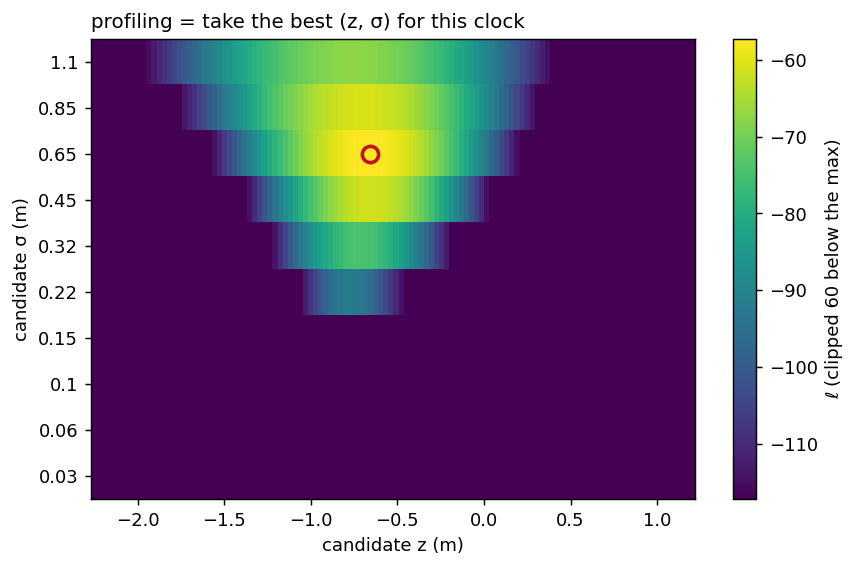

In [13]:
# the profiling surface for the ocean clock: ell over the (z, sigma) grid
L = np.array([[loglik_terms(h_tau[0.0], w_o, zc, sg)[0].sum()
               for sg in SG_GRID] for zc in Z_GRID])
fig, ax = plt.subplots(figsize=(7.5, 4.6), dpi=130)
im = ax.imshow(L.T, aspect="auto", origin="lower", cmap="viridis",
               extent=[Z_GRID[0], Z_GRID[-1], -0.5, len(SG_GRID) - 0.5],
               vmin=np.nanmax(L) - 60)
ax.set_yticks(range(len(SG_GRID))); ax.set_yticklabels(SG_GRID)
ax.plot(z0, list(SG_GRID).index(sg0), "o", ms=9, mfc="none", mec=RED, mew=2)
plt.colorbar(im, ax=ax, label="ℓ (clipped 60 below the max)")
ax.set_xlabel("candidate z (m)"); ax.set_ylabel("candidate σ (m)")
ax.set_title("profiling = take the best (z, σ) for this clock", loc="left",
             fontsize=11);

### 6c · The same sum for every clock — and the optimum

Repeat the profiling for each $\tau$ in the bank. One pixel gives a noisy
curve; MAREA sums the profiled likelihoods of the pixel's whole band, and
that is the number the decision is made on.

pixel alone: best τ = +24 min · band 5 (300 px): best τ* = +18 min

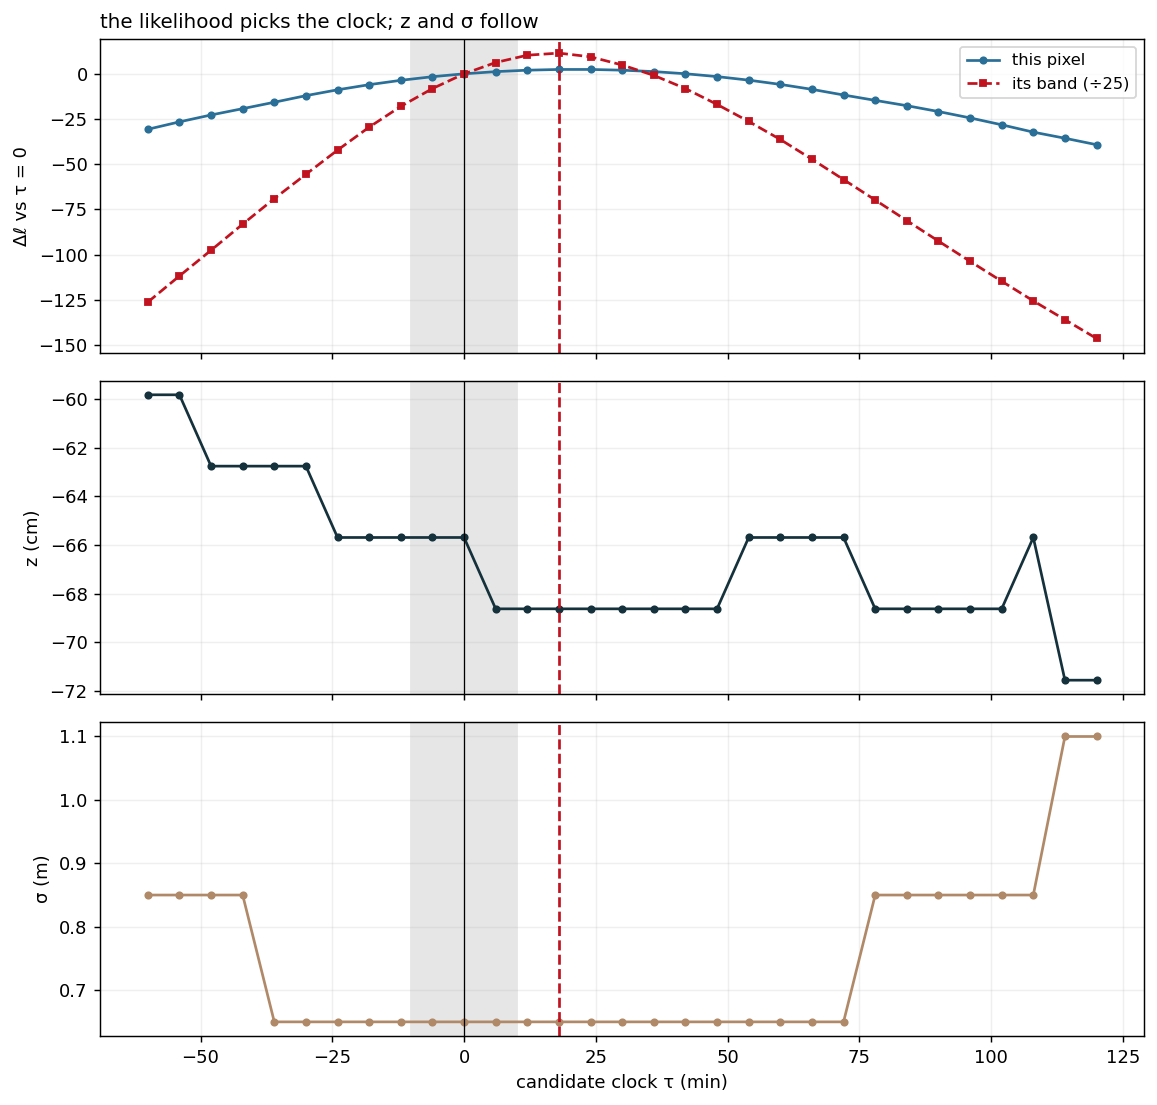

In [14]:
ll_px = np.array([profile(h_tau[float(t)], w_o)[0] for t in TAUS])
zs = np.array([profile(h_tau[float(t)], w_o)[1] for t in TAUS])
sgs = np.array([profile(h_tau[float(t)], w_o)[2] for t in TAUS])

# the band: every pixel of band k_px, its own clear record, its own profile
ds, arrays, t_dim = open_cube(cube.cache_path, cube.bands)
try:
    idx_band = keep_idx[band_of == k_px]
    rng = np.random.default_rng(7)
    if len(idx_band) > 300:
        idx_band = rng.choice(idx_band, 300, replace=False)
    rr, cc = idx_band // reference_map.shape[1], idx_band % reference_map.shape[1]
    date_pos = np.flatnonzero(obs)            # scenes in the pixel's obs set
    tot = np.zeros(len(TAUS))
    for r_, c_ in zip(rr, cc):
        g = np.asarray(arrays["B03"][:, r_, c_].values, float)[date_pos]
        n = np.asarray(arrays["B08"][:, r_, c_].values, float)[date_pos]
        s_ = np.nan_to_num(np.asarray(arrays["SCL"][:, r_, c_].values, float),
                           nan=0)[date_pos].astype(int)
        ok = np.isin(s_, list(W.CLEAR_CLASSES)) & (g + n != 0)
        if ok.sum() < 30:
            continue
        yb = ((g - n) / np.where(g + n != 0, g + n, 1) > NDWI_THRESHOLD)[ok]
        for k, t in enumerate(TAUS):
            tot[k] += profile(h_tau[float(t)][ok], yb)[0]
finally:
    ds.close()
tau_star = float(TAUS[np.argmax(tot)])
print(f"pixel alone: best τ = {TAUS[np.argmax(ll_px)]:+.0f} min · "
      f"band {k_px} ({len(rr)} px): best τ* = {tau_star:+.0f} min")

fig, axs = plt.subplots(3, 1, figsize=(9, 8.6), dpi=130, sharex=True)
axs[0].plot(TAUS, ll_px - ll_px[TAUS == 0], "o-", ms=3.5, color=TIDE,
            label="this pixel")
axs[0].plot(TAUS, (tot - tot[TAUS == 0]) / 25, "s--", ms=3, color=RED,
            label="its band (÷25)")
axs[0].set_ylabel("Δℓ vs τ = 0"); axs[0].legend(fontsize=9)
axs[1].plot(TAUS, zs * 100, "o-", ms=3.5, color=INK); axs[1].set_ylabel("z (cm)")
axs[2].plot(TAUS, sgs, "o-", ms=3.5, color=MUD); axs[2].set_ylabel("σ (m)")
axs[2].set_xlabel("candidate clock τ (min)")
for ax in axs:
    ax.axvspan(-marea.TAU_DETECT_MIN, marea.TAU_DETECT_MIN, color="0.9")
    ax.axvline(0, color="k", lw=0.7); ax.axvline(tau_star, color=RED, ls="--")
    ax.grid(alpha=0.2)
axs[0].set_title("the likelihood picks the clock; z and σ follow",
                 loc="left", fontsize=11)
fig.tight_layout();

### 6d · The decision, and what it implies

`marea.reconstruct` applies a band's clock only if $|\tau^*|$ exceeds the
detection threshold demonstrated against matched nulls
(`TAU_DETECT_MIN`), and vetoes the whole profile if any above-threshold
band is negative (the interior cannot run ahead of the ocean). What that
means for THIS pixel: a clock shift moves the level of every visit — but
in *opposite* directions on rising and falling tides (earlier on a
rising tide is lower; earlier on a falling tide is higher). The elevation
therefore moves by the NET imbalance, not by rate × τ; the two limbs'
disagreement is the contradiction the search feeds on, and it is also why
the rate × τ figure below is an upper bound.

In [15]:
applied = abs(tau_star) > marea.TAU_DETECT_MIN
print(f"band clock τ* = {tau_star:+.0f} min · threshold ±{marea.TAU_DETECT_MIN:.0f} "
      f"-> {'APPLIED' if applied else 'not applied (identity)'}")
# tide rate at the pixel's crossing level: how much level a minute buys
hs, hh = tides.series(aoi, "2024-01-01", "2024-02-01", every_hours=0.25)
hh = np.asarray(hh, float)
rate = np.abs(np.diff(hh)) / 0.25                 # m per hour
near = np.abs(hh[:-1] - z0) < 0.15
print(f"tide rate when the water crosses z = {z0:+.2f} m: "
      f"{np.median(rate[near]):.2f} m/h -> {np.median(rate[near]) / 60 * 10:.3f} m "
      f"per 10 min of clock error")
print(f"if EVERY visit moved the same way, τ* = {tau_star:+.0f} min "
      f"would be ~{np.median(rate[near]) / 60 * abs(tau_star) * 100:.0f} cm")
# ... but a clock shift moves rising and falling passes in OPPOSITE
# directions (earlier on a rising tide = lower; earlier on a falling
# tide = higher), so the elevation moves only by the NET imbalance —
# and that disagreement between the two limbs is exactly the
# contradiction the clock search feeds on
dh = h_tau[tau_star] - h_tau[0.0]
print(f"actual level change per visit: rising passes "
      f"{np.median(dh[rising]):+.2f} m, falling passes "
      f"{np.median(dh[~rising]):+.2f} m -> net median "
      f"{np.median(dh):+.2f} m")

band clock τ* = +18 min · threshold ±10 -> APPLIED

tide rate when the water crosses z = -0.66 m: 0.41 m/h -> 0.069 m per 10 min of clock error

if EVERY visit moved the same way, τ* = +18 min would be ~12 cm

actual level change per visit: rising passes -0.13 m, falling passes +0.12 m -> net median -0.01 m

## 7 · Stage: the elevation inversion — with and without the clock

The pipeline's canonical inversion is `marea.invert_series`: the same
closed-form $(a,b)$ sweep over a $\mu$ grid as the HSR estimator, with its
guards ($N\ge 8$, $0.15<b<2.5$, $|a|<2.5$), returning $(z,\sigma)$ or
NaN. It is called twice on the pixel's record: once with the ocean clock,
once with the band's — the only thing that changes is the level series
$h$. Then the numbers are set against the products already on disk.

In [16]:
Yc = y_o[:, None].astype(np.float64)
Cm = np.ones_like(Yc)
z_ocean, sg_ocean = marea.invert_series(Yc, Cm, h_tau[0.0])
z_band,  sg_band  = marea.invert_series(Yc, Cm, h_tau[tau_star])
print(f"invert_series on the ocean clock : z = {z_ocean[0]:+.3f} m · "
      f"σ = {sg_ocean[0]:.3f} m")
print(f"invert_series on the band's clock: z = {z_band[0]:+.3f} m · "
      f"σ = {sg_band[0]:.3f} m")
print(f"the clock moved this pixel's elevation by "
      f"{(z_band[0] - z_ocean[0]) * 100:+.1f} cm")

import rasterio
with rasterio.open("products_villaviciosa/hsr_eot20_2023-2025.tif") as s:
    z_hsr = float(s.read(1)[R, Cc])
print(f"shipped HSR product (epoch 2023-25, ocean clock) at the pixel: "
      f"{z_hsr:+.3f} m")
mz_path = "products_villaviciosa_marea/marea.npz"
if os.path.exists(mz_path):
    mz = np.load(mz_path)
    pos = np.flatnonzero(mz["keep"] == R * reference_map.shape[1] + Cc)
    if len(pos):
        print(f"shipped MAREA product at the pixel: z = {mz['z'][pos[0]]:+.3f} m "
              f"(band clocks applied: {np.round(mz['tau_usado_min'], 0)})")

invert_series on the ocean clock : z = -0.204 m · σ = 0.320 m

invert_series on the band's clock: z = -0.241 m · σ = 0.450 m

the clock moved this pixel's elevation by -3.7 cm

shipped HSR product (epoch 2023-25, ocean clock) at the pixel: -0.232 m

shipped MAREA product at the pixel: z = -0.266 m (band clocks applied: [ 0.  0.  0.  0.  0. 15.])

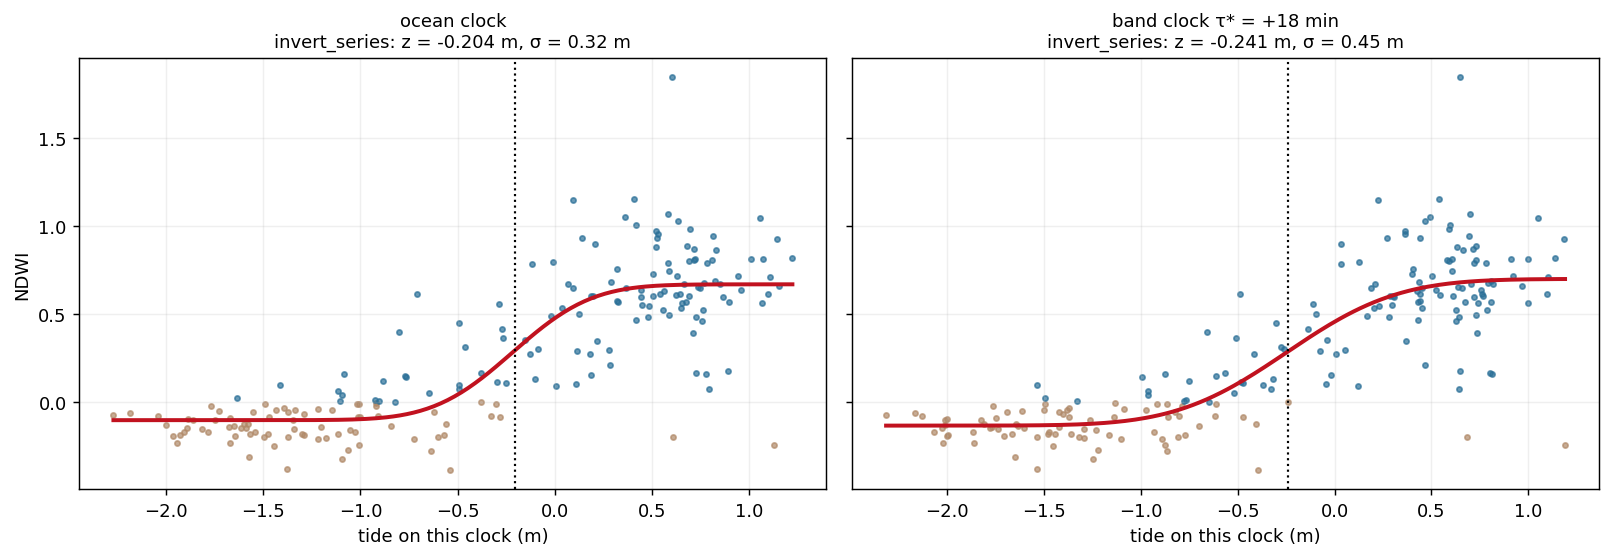

In [17]:
fig, axs = plt.subplots(1, 2, figsize=(12.5, 4.4), dpi=130, sharey=True)
for ax, tau, (zz, ss), ttl in ((axs[0], 0.0, (z_ocean[0], sg_ocean[0]),
                                 "ocean clock"),
                                (axs[1], tau_star, (z_band[0], sg_band[0]),
                                 f"band clock τ* = {tau_star:+.0f} min")):
    h = h_tau[tau]
    zc, sg, a, b, _ = fit_curve(h, y_o)
    ax.scatter(h[~w_o], y_o[~w_o], s=8, c=MUD, alpha=0.7)
    ax.scatter(h[w_o], y_o[w_o], s=8, c=TIDE, alpha=0.7)
    hg = np.linspace(h.min(), h.max(), 200)
    ax.plot(hg, a + b * ndtr((hg - zc) / sg), color=RED, lw=2.2)
    ax.axvline(zz, color="k", ls=":", lw=1.2)
    ax.set_title(f"{ttl}\ninvert_series: z = {zz:+.3f} m, σ = {ss:.2f} m",
                 fontsize=10)
    ax.set_xlabel("tide on this clock (m)"); ax.grid(alpha=0.2)
axs[0].set_ylabel("NDWI")
fig.tight_layout();

## 8 · What the pixel teaches

* Every stage's decision on this pixel was made by the pipeline's own
  rule, with numbers: usable scenes, clear visits, wet fraction, band,
  clock, elevation.
* The clock enters the elevation **only through the level series** $h$;
  the inversion code is untouched. That is why the correction is safe to
  gate: with the threshold and the veto, MAREA either improves the level
  assignment or leaves it exactly as every published method has it.
* Minutes become centimetres through the tide's rate at the pixel's own
  crossing level — the implication is site- and elevation-specific, and
  the DEM inherits it pixel by pixel.